In [1]:
import json

import numpy as np
import matplotlib.pyplot as plt

from utils import (MODELS, REGIMES, IND_ABBR, GRP_ABBR, load_data,
                   build_episodes, discrete_rollout, individual_archetypes,
                   group_archetypes)

runs, banks, P, GCLASS = load_data()
coup = json.load(open("couplings.json"))
T = 8
print("couplings for", list(coup["params"]))

couplings for ['gpt', 'gma', 'qwn', 'lma']


In [2]:
# evaluation cut: test questions on one random-graph family; real
# trajectories are the recorded single-vote spins s(0..8)
def eval_episodes(model, regime, gcut):
    ep = build_episodes(model, regime, runs, banks, P, GCLASS)
    keep = (ep["split"] == "test") & (ep["gcls"] == gcut)
    return {k: v[keep] for k, v in ep.items()}

def classes_of(traj):
    """(individual (E, 32), group (E,)) archetype indices of spin paths."""
    n = traj.mean(axis=2)                            # net opinion n(t)
    return individual_archetypes(traj), group_archetypes(n[:, 0], n[:, -1],
                                                         closed=True)

ep = eval_episodes("gpt-4o-mini", "objective", "seen")
print("gpt/objective in-distribution:", ep["spins"].shape)

gpt/objective in-distribution: (320, 9, 32)


In [3]:
# rollouts from the real s(0): deterministic (sign) and stochastic
# (Bernoulli at the rule's native temperature); classify real vs predicted
GCUTS = [("seen", "in-distribution graphs"), ("fresh", "held-out graphs")]
MODES = ["deterministic", "stochastic"]
shares = {}
for mi, (model, label, short) in enumerate(MODELS):
    for ri, regime in enumerate(REGIMES):
        b = coup["params"][short][regime]["three"]
        w = np.array(b["field"] + list(b["betas"].values()))
        for gcut, _ in GCUTS:
            ep = eval_episodes(model, regime, gcut)
            real = ep["spins"].astype(int)
            ind_r, grp_r = classes_of(real)
            for mo, mode in enumerate(MODES):
                rng = np.random.default_rng((0, mi, ri, mo))
                pred = np.concatenate(
                    [real[:, :1], discrete_rollout(ep["phi"], ep["J"],
                                                   real[:, 0], w, 3, T, mode, rng)],
                    axis=1)
                ind_p, grp_p = classes_of(pred)
                shares[short, regime, gcut, mode] = {
                    "ind_real": np.bincount(ind_r.ravel(), minlength=4) / ind_r.size,
                    "ind_model": np.bincount(ind_p.ravel(), minlength=4) / ind_r.size,
                    "grp_real": np.bincount(grp_r, minlength=5) / len(grp_r),
                    "grp_model": np.bincount(grp_p, minlength=5) / len(grp_r)}
        print(f"{label:13s} {regime:10s} done ({len(grp_r)} episodes per cut)")

GPT-4o-mini   subjective done (160 episodes per cut)


GPT-4o-mini   objective  done (320 episodes per cut)


Gemma-3n-E4B  subjective done (160 episodes per cut)


Gemma-3n-E4B  objective  done (320 episodes per cut)


Qwen3.5-9B    subjective done (160 episodes per cut)


Qwen3.5-9B    objective  done (320 episodes per cut)


Llama-3-8B    subjective done (160 episodes per cut)


Llama-3-8B    objective  done (320 episodes per cut)


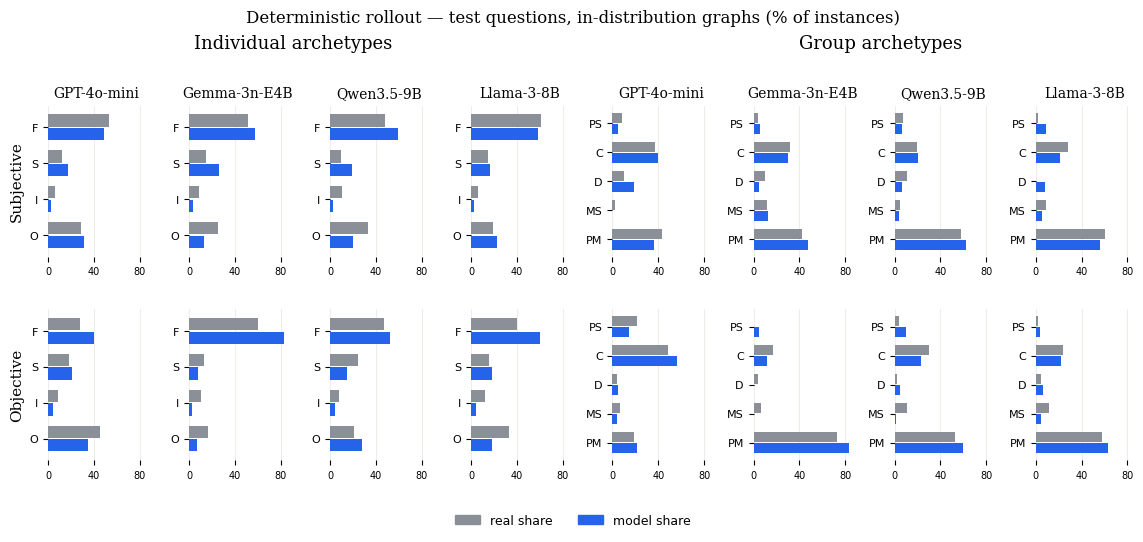

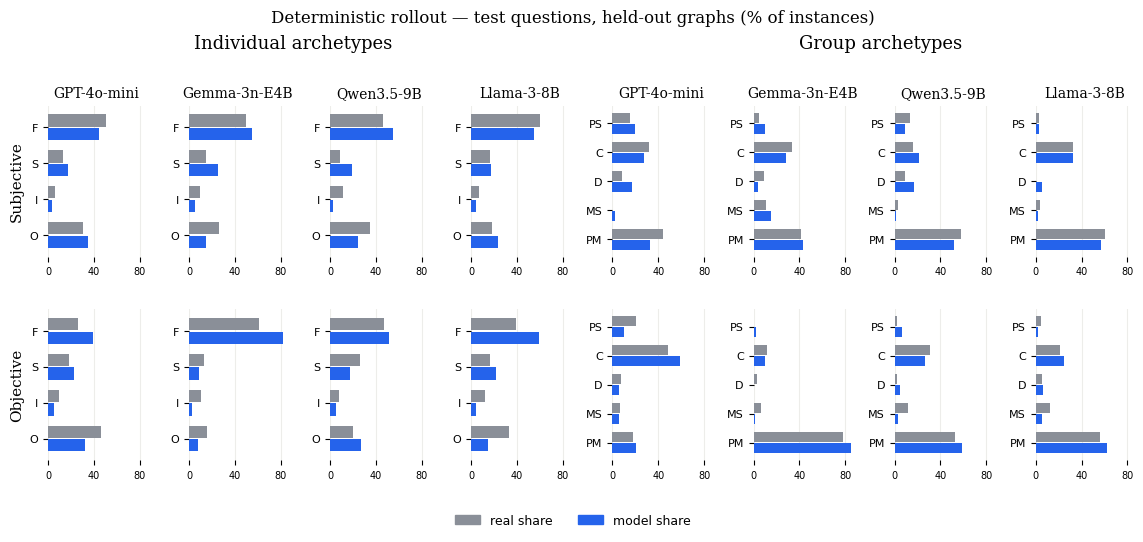

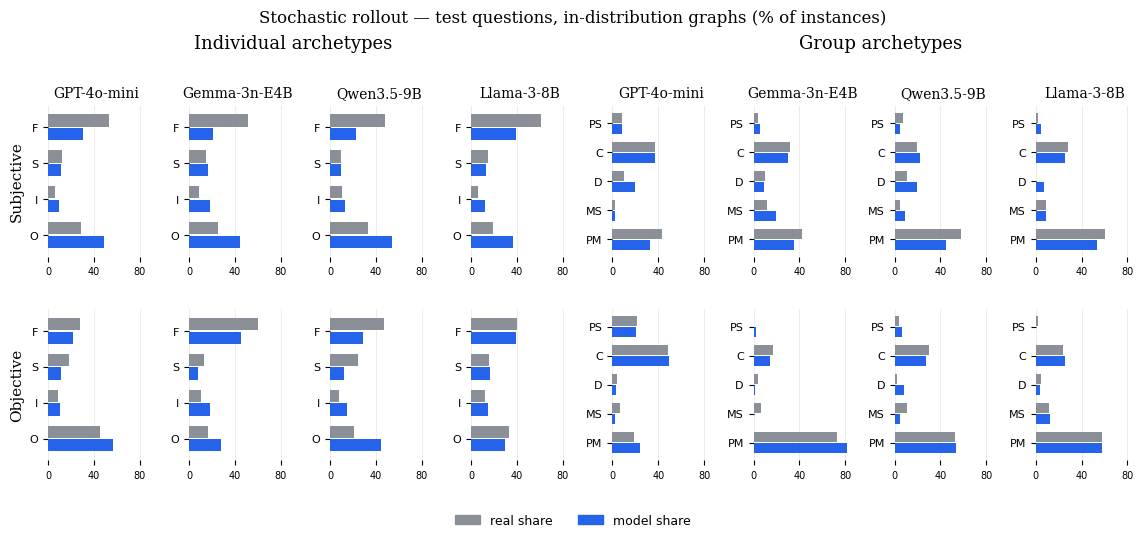

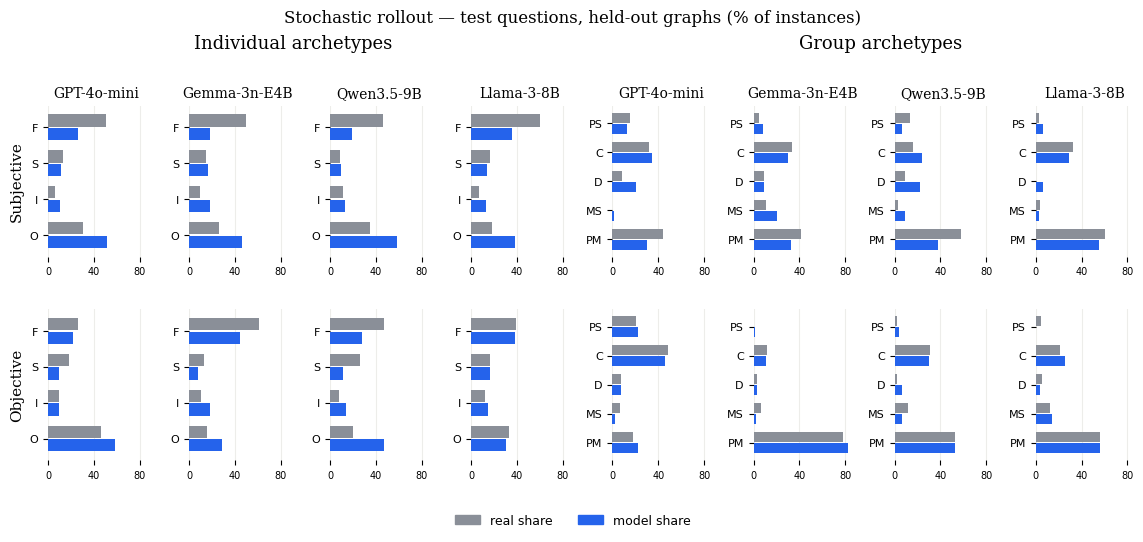

In [4]:
# real (grey) vs model (blue) archetype shares: one figure per
# (rollout mode x graph cut), individual block left, group block right
GREY, BLUE = "#8a8f98", "#2563eb"

def bar_panel(ax, real_s, model_s, abbr, title=None):
    y = np.arange(len(abbr))[::-1]
    ax.barh(y + 0.19, real_s, height=0.34, color=GREY)
    ax.barh(y - 0.19, model_s, height=0.34, color=BLUE)
    ax.set_xlim(0, 0.85), ax.set_ylim(-0.6, len(abbr) - 0.4)
    ax.set_yticks(y, abbr, fontsize=8)
    ax.set_xticks([0, 0.4, 0.8], ["0", "40", "80"], fontsize=7)
    ax.grid(axis="x", color="#ededea", lw=0.8)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, fontsize=10, family="serif")
    for s in ax.spines.values():
        s.set_visible(False)

for mode in MODES:
    for gcut, gcut_label in GCUTS:
        fig, axes = plt.subplots(2, 8, figsize=(14, 4.6),
                                 gridspec_kw=dict(wspace=0.45, hspace=0.35))
        for i, regime in enumerate(REGIMES):
            for j, (model, label, short) in enumerate(MODELS):
                sh = shares[short, regime, gcut, mode]
                bar_panel(axes[i, j], sh["ind_real"], sh["ind_model"],
                          IND_ABBR, label if i == 0 else None)
                bar_panel(axes[i, 4 + j], sh["grp_real"], sh["grp_model"],
                          GRP_ABBR, label if i == 0 else None)
            axes[i, 0].set_ylabel(regime.capitalize(), fontsize=11, family="serif")
        fig.text(0.30, 1.005, "Individual archetypes", ha="center",
                 fontsize=13, family="serif")
        fig.text(0.72, 1.005, "Group archetypes", ha="center",
                 fontsize=13, family="serif")
        fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=GREY, label="real share"),
                            plt.Rectangle((0, 0), 1, 1, color=BLUE, label="model share")],
                   loc="lower center", ncol=2, fontsize=9, frameon=False,
                   bbox_to_anchor=(0.5, -0.06))
        fig.suptitle(f"{mode.capitalize()} rollout — test questions, "
                     f"{gcut_label} (% of instances)", fontsize=12,
                     family="serif", y=1.09)
        plt.show()

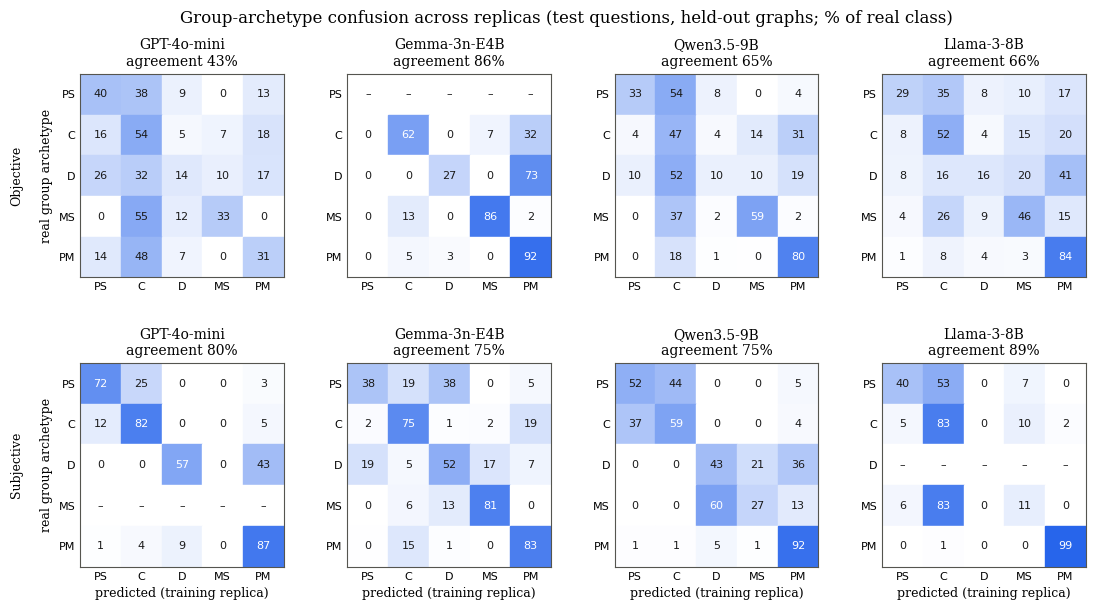

In [5]:
def replica_confusion(model, regime):
    ep = eval_episodes(model, regime, "fresh")
    grp = classes_of(ep["spins"].astype(int))[1]
    cells = {}
    for e, (q, g, rep) in enumerate(zip(ep["qid"], ep["gid"], ep["rep"])):
        cells.setdefault((q, g), {})[rep] = e
    conf = np.zeros((4, 5, 5))
    for cell in cells.values():
        for r, er in cell.items():
            for ro, eo in cell.items():
                if ro != r:
                    conf[r, grp[eo], grp[er]] += 1   # rows real, cols predicted
    return conf.mean(axis=0)

def shade(frac):
    return (1 - frac * 218 / 255, 1 - frac * 156 / 255, 1 - frac * 20 / 255)

fig, axes = plt.subplots(2, 4, figsize=(13, 6.4),
                         gridspec_kw=dict(wspace=0.3, hspace=0.42))
for i, regime in enumerate(["objective", "subjective"]):
    for j, (model, label, short) in enumerate(MODELS):
        ax = axes[i, j]
        conf = replica_confusion(model, regime)
        row_tot = conf.sum(axis=1)
        agree = 100 * np.trace(conf) / conf.sum()
        for a in range(5):
            for b in range(5):
                v = conf[a, b] / row_tot[a] if row_tot[a] else 0.0
                ax.add_patch(plt.Rectangle((b, 4 - a), 1, 1, color=shade(v)))
                ax.text(b + 0.5, 4 - a + 0.5,
                        "–" if not row_tot[a] else f"{100 * v:.0f}",
                        ha="center", va="center", fontsize=8,
                        color="white" if v > 0.55 else "#1a1a1a")
        ax.set_xlim(0, 5), ax.set_ylim(0, 5)
        ax.set_xticks(np.arange(5) + 0.5, GRP_ABBR, fontsize=8)
        ax.set_yticks(np.arange(5)[::-1] + 0.5, GRP_ABBR, fontsize=8)
        ax.set_aspect("equal")
        ax.tick_params(length=0)
        ax.set_title(f"{label}\nagreement {agree:.0f}%", fontsize=10,
                     family="serif")
        if j == 0:
            ax.set_ylabel(f"{regime.capitalize()}\n\nreal group archetype",
                          fontsize=9, family="serif")
        if i == 1:
            ax.set_xlabel("predicted (training replica)", fontsize=9,
                          family="serif")
        for s in ax.spines.values():
            s.set_color("#55554f")
fig.suptitle("Group-archetype confusion across replicas "
             "(test questions, held-out graphs; % of real class)",
             fontsize=12, family="serif")
plt.show()